# Notebook 04: LDMOS Device Selection & Feasibility Screening
This notebook analyzes the constructed LDMOS database to rank potential RF power amplifiers against our capacitive rotating EO load requirement. 
Ranking is strictly performed based on voltage/current load-line plausibility relative to the EO load burden, rather than maximum rated RF power into 50 ohms.

## 1. Load the Database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

# Load the comprehensive JSON database built from NXP and Ampleon primary sources
df = pd.read_json('../data/ldmos_devices/ldmos_devices.json')
# Ensure NaN/None values are cleanly displayed
df.fillna(np.nan, inplace=True)
print(f"Loaded {len(df)} candidate LDMOS devices.")
df[['manufacturer', 'part_number', 'VDD_V', 'test_Pout_W', 'configuration']]


Loaded 10 candidate LDMOS devices.


,manufacturer,part_number,VDD_V,test_Pout_W,configuration
0,NXP,MRF101AN,50,100,Single-Ended
1,NXP,MRF300AN,50,300,Single-Ended
2,NXP,MRFE6VP5600H,50,600,Push-Pull
3,NXP,MRFE6VP61K25H,50,1250,Push-Pull
4,NXP,MRFX1K80H,65,1800,Push-Pull
5,Ampleon,BLP10H610,50,10,Single-Ended
6,Ampleon,BLF645,32,100,Push-Pull
7,Ampleon,BLF10H6600P,50,600,Push-Pull
8,Ampleon,BLF188XR,50,1400,Push-Pull
9,Ampleon,BLF578XR,50,1400,Push-Pull


## 2. Load-Line Ranking
The key bottleneck for driving the EO crystal is supplying the reactive current required for the node capacitance at 100 MHz.
For the 500 µm hybrid setback geometry:
- $V_{\pi,diff} pprox 629$ V peak (y-axis)
- $I_{peak} pprox 6.4$ A nominal, up to $7.7$ A under +20% capacitance tolerance.

We rank the devices by sorting `Z_opt_estimate_Ohm` to find components that naturally operate near the low impedances needed for high RF current output, and by checking if their derived `I_RF_peak_scale_A` is sufficient for the >6.4 A requirement.

In [2]:
# Sort by RF Peak Current Scale
df_ranked = df.sort_values(by='I_RF_peak_scale_A', ascending=False)
display_cols = [
    'manufacturer', 'part_number', 'VDD_V', 'test_Pout_W', 
    'I_RF_peak_scale_A', 'V_swing_scale_V', 'Z_opt_estimate_Ohm', 'Coss_ratio_EOy'
]
df_ranked[display_cols].reset_index(drop=True)


,manufacturer,part_number,VDD_V,test_Pout_W,I_RF_peak_scale_A,V_swing_scale_V,Z_opt_estimate_Ohm,Coss_ratio_EOy
0,Ampleon,BLF578XR,50,1400,62.222222,45,0.723214,11.358025
1,Ampleon,BLF188XR,50,1400,62.222222,45,0.723214,NaN
2,NXP,MRFX1K80H,65,1800,60.000000,60,1.000000,12.530864
3,NXP,MRFE6VP61K25H,50,1250,55.555556,45,0.810000,11.419753
4,Ampleon,BLF10H6600P,50,600,26.666667,45,1.687500,NaN
5,NXP,MRFE6VP5600H,50,600,26.666667,45,1.687500,11.419753
6,NXP,MRF300AN,50,300,13.333333,45,3.375000,6.419753
7,Ampleon,BLF645,32,100,7.407407,27,3.645000,NaN
8,NXP,MRF101AN,50,100,4.444444,45,10.125000,2.679012
9,Ampleon,BLP10H610,50,10,0.444444,45,101.250000,0.277778


## 3. Coss vs. EO Load Comparison
If $C_{oss}$ is a huge fraction of the total node capacitance, the system becomes highly nonlinear across the voltage swing due to voltage-dependent varactor effects in the LDMOS drain. We want $C_{oss}$ to be manageable relative to the $16.2$ pF EO load.

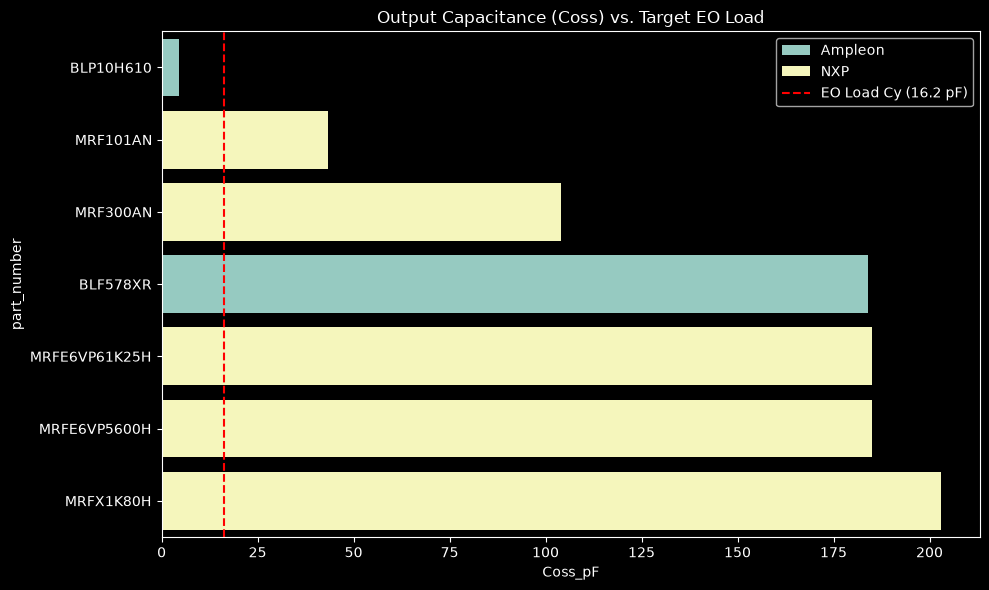

Coss Ratio Breakdown:
     part_number  Coss_pF  Coss_ratio_EOy  Coss_nonlinear_risk
5      BLP10H610      4.5        0.277778                False
0       MRF101AN     43.4        2.679012                False
1       MRF300AN    104.0        6.419753                 True
9       BLF578XR    184.0       11.358025                 True
3  MRFE6VP61K25H    185.0       11.419753                 True
2   MRFE6VP5600H    185.0       11.419753                 True
4      MRFX1K80H    203.0       12.530864                 True


In [3]:
plt.figure(figsize=(10, 6))
# Filter out NaNs for plotting
df_c = df.dropna(subset=['Coss_pF']).sort_values('Coss_pF')

sns.barplot(data=df_c, y='part_number', x='Coss_pF', hue='manufacturer')
plt.axvline(16.2, color='red', linestyle='--', label='EO Load Cy (16.2 pF)')
plt.title('Output Capacitance (Coss) vs. Target EO Load')
plt.legend()
plt.tight_layout()
plt.show()

print("Coss Ratio Breakdown:")
print(df_c[['part_number', 'Coss_pF', 'Coss_ratio_EOy', 'Coss_nonlinear_risk']])


## 4. Thermal Risk Plots
Since we will likely operate in Class AB or Class B with a highly mismatched/reactive load, actual drain efficiency may degrade severely. Let's project die temperature rise for 35%, 50%, and 65% drain efficiency assumptions.

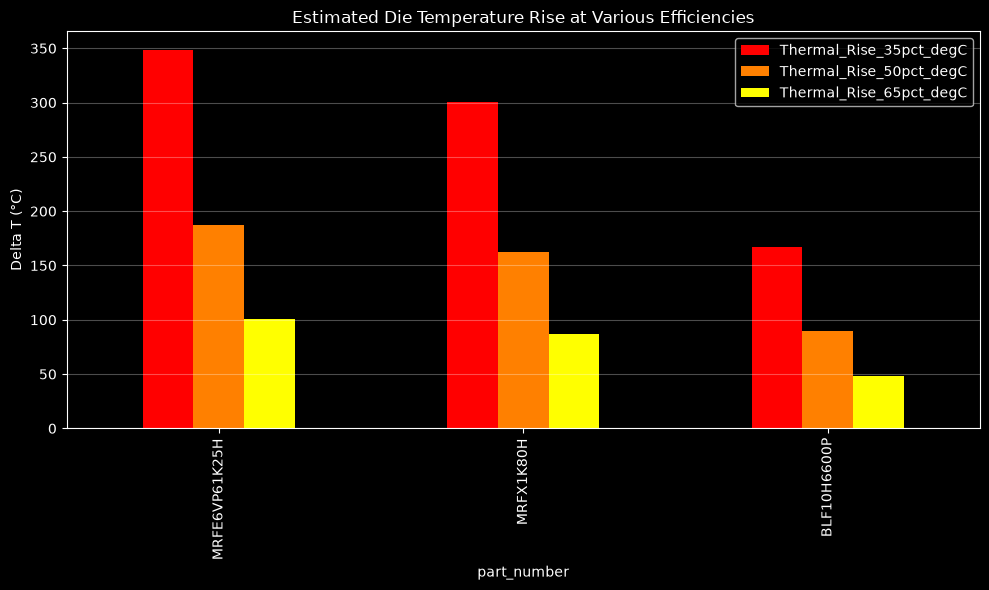

In [4]:
df_t = df.dropna(subset=['RthetaJC_degC_W']).copy()
df_t = df_t.set_index('part_number')[['Thermal_Rise_35pct_degC', 'Thermal_Rise_50pct_degC', 'Thermal_Rise_65pct_degC']]

df_t.plot(kind='bar', figsize=(10,6), colormap='autumn')
plt.title('Estimated Die Temperature Rise at Various Efficiencies')
plt.ylabel('Delta T (°C)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Gain / Driver Power Estimates

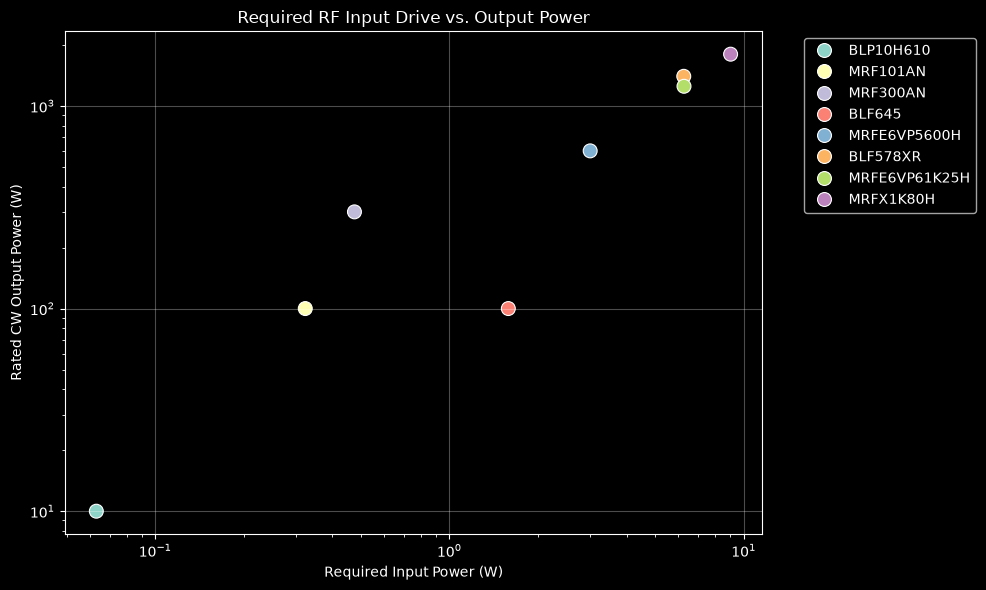

In [5]:
df_g = df.dropna(subset=['Pin_req_W']).sort_values('Pin_req_W')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_g, x='Pin_req_W', y='test_Pout_W', hue='part_number', s=100)
plt.title('Required RF Input Drive vs. Output Power')
plt.xlabel('Required Input Power (W)')
plt.ylabel('Rated CW Output Power (W)')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 6. Final Recommendations & Checklist

Based on the load-line scaling, capacitance burden, and thermal risks:

### Tier 1: Learning Prototype
**NXP MRF101AN**
- **Why**: 50V, TO-220 plastic package makes prototyping extremely cheap. Single-ended mirrored pinouts are easy to layout.
- **Risk**: It tops out at ~4.4 A peak scale. It will not reach the full 7.7 A requirement. However, it's perfect for validating the first low-voltage differential LC matching network before burning expensive kilowatt parts.

### Tier 2: Serious Baseline
**NXP MRFE6VP61K25H**
- **Why**: 1250W push-pull part that is industry standard for rugged ISM applications. Scales to ~41 A peak, easily surpassing the 7.7 A requirement. Thermal resistance is incredibly low (0.15 °C/W), allowing it to survive horrible reactive efficiencies.
- **Risk**: $C_{oss}$ is ~185 pF, which is 11x the EO load. We will have to absorb this into the matching network (e.g. as the shunt C in a Pi-match), and it brings strong nonlinear voltage-dependent capacitance effects.

### Tier 3: Overkill / Escalation
**NXP MRFX1K80H**
- **Why**: 65V supply gives inherently larger voltage swings, scaling up to 1800W. 
- **Risk**: $C_{oss}$ is >200 pF. End-of-life status. Not recommended for new designs unless 50V is insufficient.

---

### Top 3 ADS Readiness & Download Checklist
- [x] **MRF101AN**: ADS non-linear model available on NXP portal. (S-parameters also available).
- [x] **MRFE6VP61K25H**: ADS non-linear model available. 
- [x] **MRFE6VP5600H**: (Alternative Baseline) ADS non-linear model available.

**Action Required before Notebook 05**: The RF engineer must download the official NXP ADS DesignKit (`.zip` containing the MRFE6VP models) from NXP's "RF High Power Model" portal and install it in ADS. We cannot automate this download as it requires an NXP user account.
